# Refactored Fake News Detection Pipeline

This notebook demonstrates the use of the refactored `src` modules for the entire pipeline:
1. Data Processing (Cleaning & Tokenization)
2. Train/Test Split
3. Feature Engineering (TF-IDF & Word2Vec)
4. Model Training & Evaluation


In [12]:
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Add project root to path to import src
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import refactored modules (with reload to pick up changes)
from src.data import process_dataset, make_split, load_kaggle_dataset
from src.features import make_features
from src.models import train_model as train_model_module

importlib.reload(make_features)
importlib.reload(train_model_module)

run_feature_engineering = make_features.run_feature_engineering
train_model = train_model_module.train_model
load_config = train_model_module.load_config


## 1. Data Processing


In [2]:
# Define paths
config = load_config(str(project_root / "config" / "config.yaml"))
raw_data_path = project_root / "data" / "raw" / "WELFake_Dataset.csv"
processed_data_path = project_root / "data" / "processed" / "preprocessed_dataset.csv"

# Run processing
print("Running data processing...")
df = process_dataset(str(raw_data_path), str(processed_data_path))


Running data processing...
Starting data preprocessing...
Input: /Users/alanye/Fake-News-Group-3/data/raw/WELFake_Dataset.csv
Output: /Users/alanye/Fake-News-Group-3/data/processed/preprocessed_dataset.csv

1. Loading dataset...
   Loaded 72134 rows, 4 columns
   Columns: ['id', 'title', 'text', 'label']

2. Tokenizing text...
   ✓ Basic tokenization complete

3. Applying preprocessing pipeline...
   - Lowercasing
   - Removing punctuation
   - Removing stopwords
   - Removing short tokens (< 3 chars)
   - Lemmatizing
   ✓ Preprocessing complete

4. Sample statistics:
   Original text length: 5049 chars
   Basic tokens: 912 tokens
   Processed tokens: 451 tokens
   Example tokens: ['comment', 'expect', 'barack', 'obama', 'members', 'fyf911', 'fukyoflag', 'blacklivesmatter', 'movements', 'call']

5. Saving processed data...
✓ Saved 72134 rows to /Users/alanye/Fake-News-Group-3/data/processed/preprocessed_dataset.csv

✓ Preprocessing complete!
  Saved columns: ['id', 'title', 'text', 'to

## 2. Create Train/Test Split


In [3]:
print("Creating train/test split...")
processed_dir = project_root / "data" / "processed"

train_df, test_df = make_split(
    input_path=str(processed_data_path),
    output_dir=str(processed_dir),
    test_size=config["models"]["test_size"],
    random_seed=config["models"]["random_seed"]
)


Creating train/test split...
Loading data from /Users/alanye/Fake-News-Group-3/data/processed/preprocessed_dataset.csv...
Applying source leakage cleaning to 'text' column...
Checking for duplicates...
Removed 9415 duplicate rows. New size: 62719
Splitting data (test_size=0.2, random_seed=42)...
Saving train set to /Users/alanye/Fake-News-Group-3/data/processed/train.csv (50175 rows)...
Saving test set to /Users/alanye/Fake-News-Group-3/data/processed/test.csv (12544 rows)...
Split complete!


In [6]:
train_df

,id,title,text,tokens,processed_tokens,label
21964,21964,Watchdog Claims 5K Noncitizens Registered to V...,A new report released shortly after the formin...,"['A', 'new', 'report', 'released', 'shortly', ...","['new', 'report', 'release', 'shortly', 'form'...",0
34239,34239,France to discuss possible new Rafale sale wit...,France will discuss the possible sale of more ...,"['PARIS', 'Reuters', 'France', 'will', 'discus...","['paris', 'reuters', 'france', 'discuss', 'pos...",0
8776,8776,WATCH: GOP Governor Tells Christians To Marty...,This is why we have separation of church and s...,"['This', 'is', 'why', 'we', 'have', 'separatio...","['separation', 'church', 'state', 'guard', 'co...",1
32414,32414,Philippines to ask China to clarify its intent...,"Philippine President Rodrigo Duterte, in an ap...","['MANILA', 'Reuters', 'Philippine', 'President...","['manila', 'reuters', 'philippine', 'president...",0
19127,19127,The BBC Asks – What Really Happened With the C...,at 11:54 am 4 Comments \nWhen it comes to the ...,"['at', '11', '54', 'am', '4', 'Comments', 'Whe...","['1154', 'comment', 'come', 'clintons', 'smoke...",1
...,...,...,...,...,...,...
386,386,Comment on World Heaves Sigh of Relief after T...,Finian Cunningham has written extensively on...,"['Finian', 'Cunningham', 'has', 'written', 'ex...","['finian', 'cunningham', 'write', 'extensively...",1
30795,30795,ALARMING! THIS STATE’S SCHOOL SYSTEM TO TAKE O...,The ultimate nanny state move in this liberal ...,"['The', 'ultimate', 'nanny', 'state', 'move', ...","['ultimate', 'nanny', 'state', 'move', 'libera...",1
45964,45964,Merkel optimistic EU dispute over refugee dist...,German Chancellor Angela Merkel said she was o...,"['BERLIN', 'Reuters', 'German', 'Chancellor', ...","['berlin', 'reuters', 'german', 'chancellor', ...",0
44271,44271,Global Warming Scammer Makes Millions BUT Is J...,Global warming has been shoved down the throat...,"['Global', 'warming', 'has', 'been', 'shoved',...","['global', 'warm', 'shove', 'throats', 'every'...",1


In [7]:
test_df

,id,title,text,tokens,processed_tokens,label
62942,62942,Newt Gingrich Defends Donald Trump Against 'Se...,\nDonald Trump supporter and former Speaker o...,"['Donald', 'Trump', 'supporter', 'and', 'forme...","['donald', 'trump', 'supporter', 'former', 'sp...",1
69764,69764,U.S. lawmakers reach deal for Senate Russia sa...,WASHINGTON/MOSCOW/BRUSSELS (Reuters) - U.S. la...,"['WASHINGTON', 'MOSCOW', 'BRUSSELS', 'Reuters'...","['washingtonmoscowbrussels', 'reuters', 'lawma...",0
20260,20260,KKK Just Threatened An 84-Year-Old Woman Who ...,An elderly Massachussetts woman who wrote a le...,"['An', 'elderly', 'Massachussetts', 'woman', '...","['elderly', 'massachussetts', 'woman', 'write'...",1
8886,8886,Uber Releases Diversity Report and Repudiates ...,SAN FRANCISCO — After a string of scandals ...,"['SAN', 'FRANCISCO', 'After', 'a', 'string', '...","['san', 'francisco', 'string', 'scandals', 'ye...",0
21240,21240,WATCH: Republican Heartlessly Tells A Mother ...,Wow. The cruelty of Republicans knows no bound...,"['Wow', 'The', 'cruelty', 'of', 'Republicans',...","['wow', 'cruelty', 'republicans', 'know', 'bou...",1
...,...,...,...,...,...,...
57770,57770,"Trump to scrap protection for 'Dreamers,' give...",President Donald Trump has decided to scrap a ...,"['WASHINGTON', 'Reuters', 'President', 'Donald...","['washington', 'reuters', 'president', 'donald...",0
42921,42921,Norway government to rule in minority after ce...,Norway s Christian Democratic party withdrew f...,"['OSLO', 'Reuters', 'Norway', 's', 'Christian'...","['oslo', 'reuters', 'norway', 'christian', 'de...",0
3982,3982,It’s Children Against Federal Lawyers in Immig...,"TUCSON — After a long, scary trek through t...","['TUCSON', 'After', 'a', 'long', 'scary', 'tre...","['tucson', 'long', 'scary', 'trek', 'three', '...",0
43371,43371,Report: US Investigators Had Concern That Brad...,"Apparently, Tom Brady’s missing Super Bowl jer...","['Apparently', 'Tom', 'Brady', 's', 'missing',...","['apparently', 'tom', 'brady', 'miss', 'super'...",0


## 3. Feature Engineering


In [4]:
print("Running feature engineering (TF-IDF & Word2Vec)...")
# This function handles loading split data, fitting vectorizers, and saving features
run_feature_engineering(str(processed_dir))


Running feature engineering (TF-IDF & Word2Vec)...
Loading train/test split...
Creating TF-IDF features (fit on training text only)...
Applying leakage cleaning (removing source attribution)...
Creating Word2Vec/Sentence2Vec features...
Training Word2Vec model...
Generating Sentence2Vec features...
Generating Sentence2Vec features for test set...
Saving TF-IDF features...
Saving Word2Vec features and model...
Feature engineering complete!


## 4. Model Training & Evaluation


In [13]:
# Train Ridge Classifier
print("Training Ridge Classifier...")
ridge_model, ridge_metrics, ridge_preds = train_model(
    "ridge_classifier", config, return_metrics=True,
    processed_dir=str(processed_dir),
    models_dir=str(project_root / "results" / "models")
)


Training Ridge Classifier...
Loading TF-IDF features...
Training ridge_classifier...
Evaluating on test set...
Accuracy: 0.9373
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      6924
           1       0.94      0.92      0.93      5620

    accuracy                           0.94     12544
   macro avg       0.94      0.94      0.94     12544
weighted avg       0.94      0.94      0.94     12544

Model saved to /Users/alanye/Fake-News-Group-3/results/models/ridge_classifier.pkl


In [14]:
# Train Logistic Regression
print("Training Logistic Regression...")
lr_model, lr_metrics, lr_preds = train_model(
    "logistic_regression", config, return_metrics=True,
    processed_dir=str(processed_dir),
    models_dir=str(project_root / "results" / "models")
)


Training Logistic Regression...
Loading TF-IDF features...
Training logistic_regression...
Evaluating on test set...
Accuracy: 0.9338
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6924
           1       0.93      0.92      0.93      5620

    accuracy                           0.93     12544
   macro avg       0.93      0.93      0.93     12544
weighted avg       0.93      0.93      0.93     12544

Model saved to /Users/alanye/Fake-News-Group-3/results/models/logistic_regression.pkl


### Comparison


Model Comparison:
Ridge Classifier Accuracy: 0.9373
Logistic Regression Accuracy: 0.9338


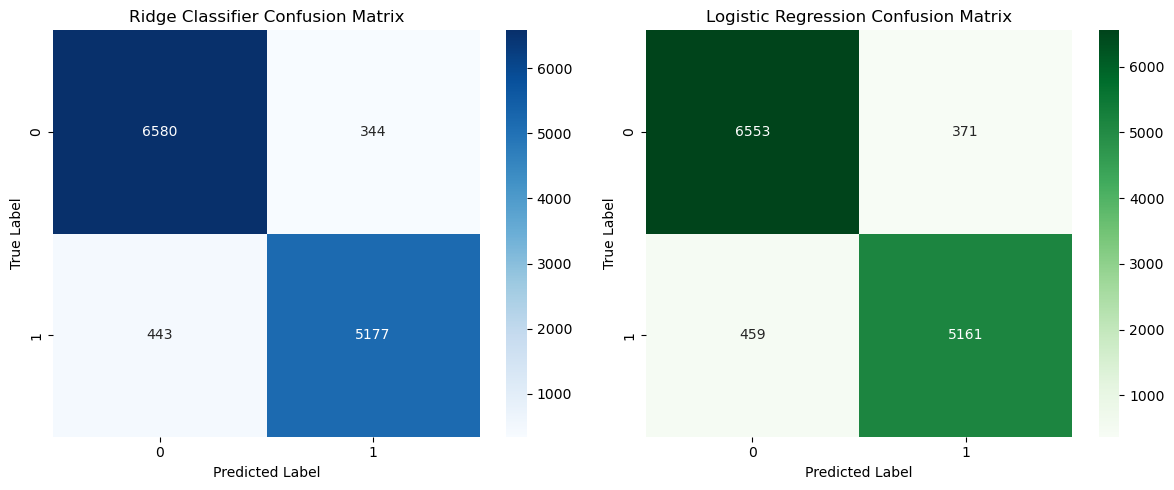

In [15]:
print("Model Comparison:")
print(f"Ridge Classifier Accuracy: {ridge_metrics['accuracy']:.4f}")
print(f"Logistic Regression Accuracy: {lr_metrics['accuracy']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ridge Confusion Matrix
sns.heatmap(ridge_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Ridge Classifier Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Logistic Regression Confusion Matrix
sns.heatmap(lr_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


## 5. Feature Importance Analysis

Compare the most important features (words/n-grams) for each model to understand what drives predictions.


In [16]:
import joblib
import numpy as np

# Load the TF-IDF vectorizer to get feature names
vectorizer = joblib.load(str(processed_dir / "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()

def get_top_features(model, feature_names, n=20):
    """Extract top positive and negative features from a linear model."""
    coefs = model.coef_[0] if model.coef_.ndim > 1 else model.coef_
    
    # Create DataFrame with features and coefficients
    df_features = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefs,
        'abs_coef': np.abs(coefs)
    })
    
    # Top features predicting FAKE (positive coefficients)
    top_fake = df_features.nlargest(n, 'coefficient')[['feature', 'coefficient']]
    
    # Top features predicting REAL (negative coefficients)
    top_real = df_features.nsmallest(n, 'coefficient')[['feature', 'coefficient']]
    
    return top_fake, top_real

# Get top features for both models
ridge_fake, ridge_real = get_top_features(ridge_model, feature_names)
lr_fake, lr_real = get_top_features(lr_model, feature_names)


In [17]:
# Display top features for Ridge Classifier
print("=" * 60)
print("RIDGE CLASSIFIER - TOP FEATURES")
print("=" * 60)

print("\n--- Top 20 Indicators of FAKE News ---")
print(ridge_fake.to_string(index=False))

print("\n--- Top 20 Indicators of REAL News ---")
print(ridge_real.to_string(index=False))


RIDGE CLASSIFIER - TOP FEATURES

--- Top 20 Indicators of FAKE News ---
             feature  coefficient
      featured image     4.346204
         twitter com     3.832016
              donate     2.742020
              flickr     2.692584
               getty     2.322269
                read     2.144407
            featured     2.044742
               image     2.028093
        getty images     1.812096
              caller     1.524446
       controversial     1.410123
2017 realdonaldtrump     1.244694
            year old     1.213603
              source     1.209950
        century wire     1.191227
          permission     1.183094
          daily mail     1.149806
     president trump     1.143470
               print     1.140964
                  ed     1.106191

--- Top 20 Indicators of REAL News ---
         feature  coefficient
          follow    -3.812380
president donald    -3.697065
            said    -2.841568
         twitter    -2.255160
president barack    -1.9

In [18]:
# Display top features for Logistic Regression
print("=" * 60)
print("LOGISTIC REGRESSION - TOP FEATURES")
print("=" * 60)

print("\n--- Top 20 Indicators of FAKE News ---")
print(lr_fake.to_string(index=False))

print("\n--- Top 20 Indicators of REAL News ---")
print(lr_real.to_string(index=False))


LOGISTIC REGRESSION - TOP FEATURES

--- Top 20 Indicators of FAKE News ---
       feature  coefficient
featured image    11.622967
      featured    10.216181
         image     9.836475
   twitter com     8.868077
         getty     7.430112
  getty images     7.030127
       hillary     6.717092
          read     6.602858
       october     6.579502
          2016     5.836035
           com     5.452664
      november     5.279410
         watch     4.840928
          anti     4.402191
 november 2016     4.289168
        donate     4.276143
          just     4.233470
        images     4.056975
        flickr     3.848459
        entire     3.785705

--- Top 20 Indicators of REAL News ---
         feature  coefficient
            said   -13.483730
president donald   -10.561380
          follow   -10.401580
         twitter    -7.574057
         reuters    -7.321813
        thursday    -6.793269
          friday    -6.418000
         tuesday    -6.240786
       wednesday    -5.7956

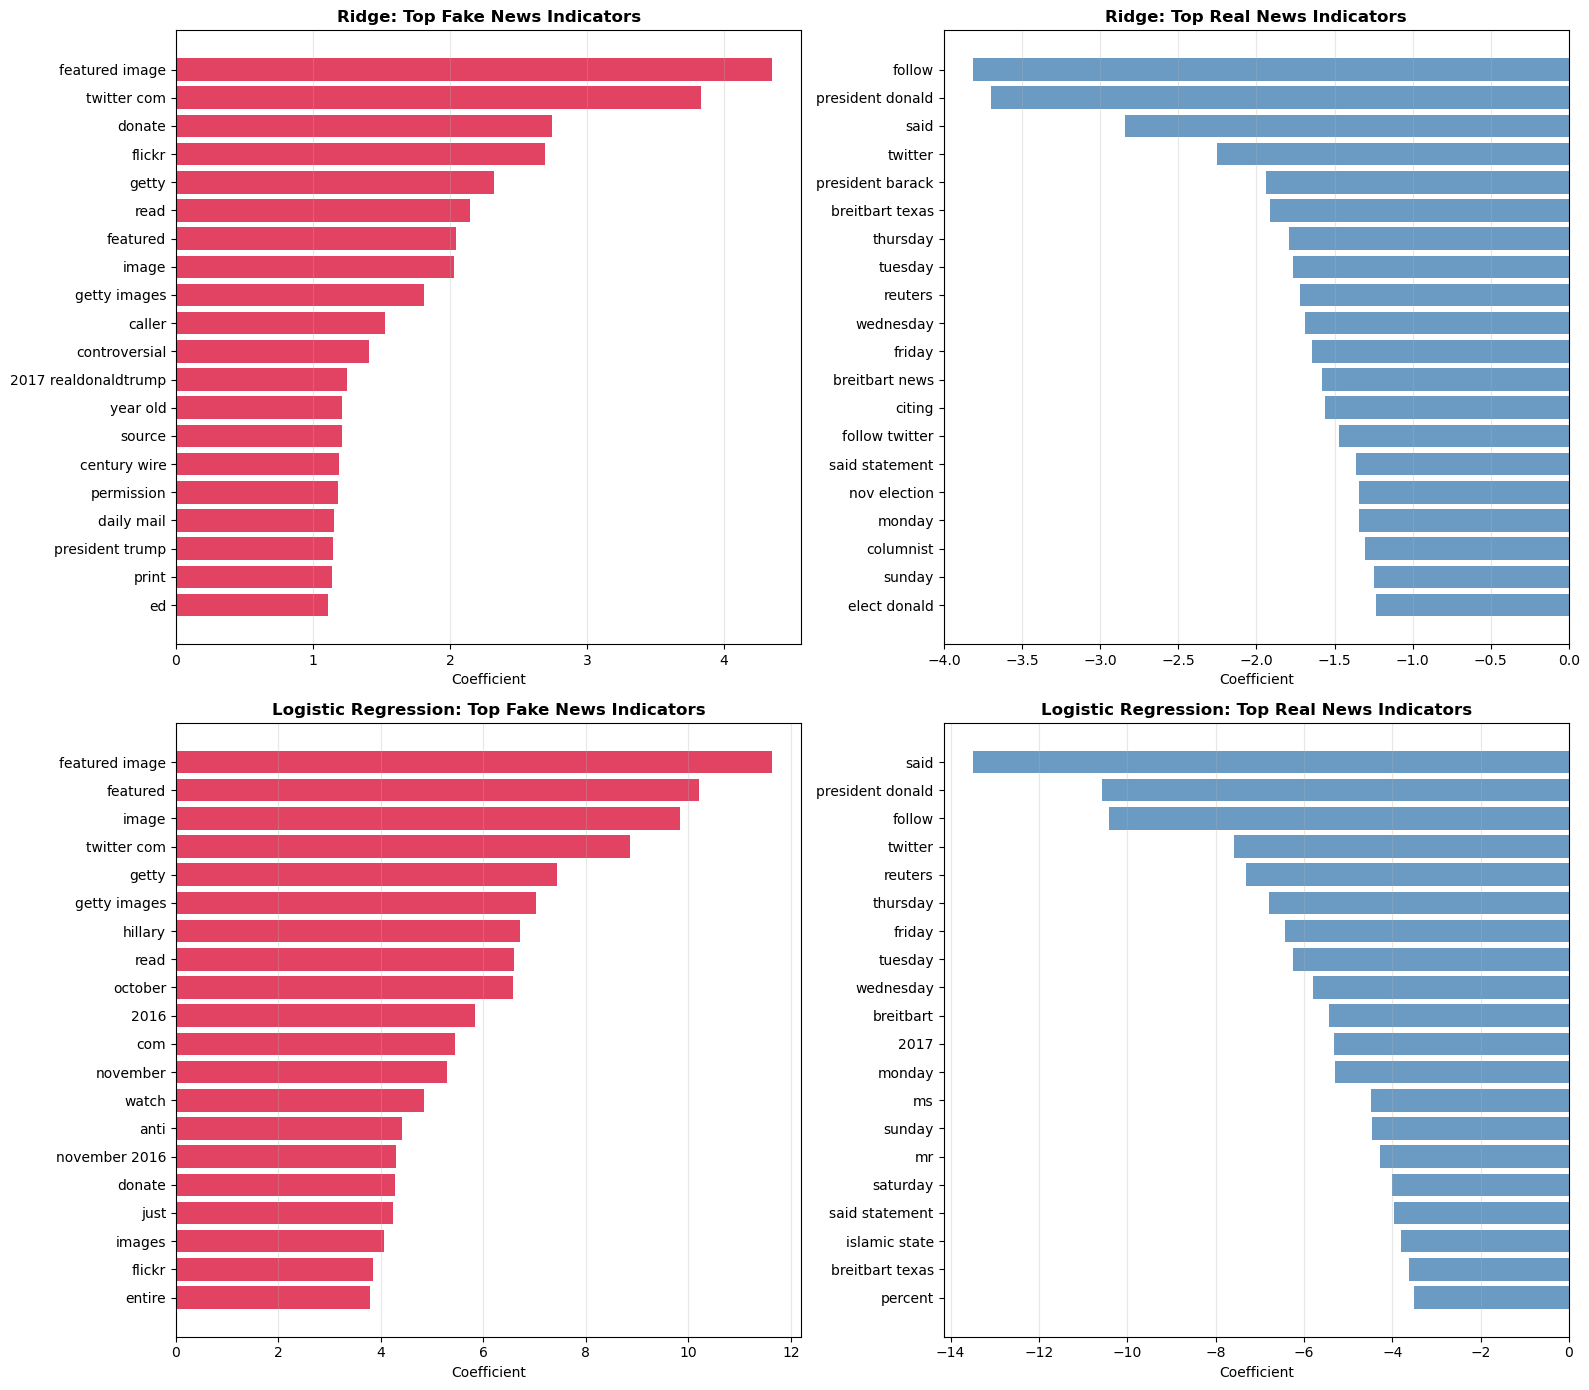

In [19]:
# Visual comparison of feature importance
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Ridge - Fake indicators
ax = axes[0, 0]
y_pos = np.arange(len(ridge_fake))
ax.barh(y_pos, ridge_fake['coefficient'].values, color='crimson', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(ridge_fake['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Coefficient')
ax.set_title('Ridge: Top Fake News Indicators', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Ridge - Real indicators
ax = axes[0, 1]
y_pos = np.arange(len(ridge_real))
ax.barh(y_pos, ridge_real['coefficient'].values, color='steelblue', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(ridge_real['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Coefficient')
ax.set_title('Ridge: Top Real News Indicators', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Logistic Regression - Fake indicators
ax = axes[1, 0]
y_pos = np.arange(len(lr_fake))
ax.barh(y_pos, lr_fake['coefficient'].values, color='crimson', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(lr_fake['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression: Top Fake News Indicators', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Logistic Regression - Real indicators
ax = axes[1, 1]
y_pos = np.arange(len(lr_real))
ax.barh(y_pos, lr_real['coefficient'].values, color='steelblue', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(lr_real['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression: Top Real News Indicators', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
# Compare overlap between models - which features do both models agree on?
ridge_fake_set = set(ridge_fake['feature'].values)
ridge_real_set = set(ridge_real['feature'].values)
lr_fake_set = set(lr_fake['feature'].values)
lr_real_set = set(lr_real['feature'].values)

fake_overlap = ridge_fake_set & lr_fake_set
real_overlap = ridge_real_set & lr_real_set

print("=" * 60)
print("FEATURE OVERLAP BETWEEN MODELS")
print("=" * 60)

print(f"\nFake News Indicators (both models agree): {len(fake_overlap)}/20")
print(sorted(fake_overlap))

print(f"\nReal News Indicators (both models agree): {len(real_overlap)}/20")
print(sorted(real_overlap))


FEATURE OVERLAP BETWEEN MODELS

Fake News Indicators (both models agree): 9/20
['donate', 'featured', 'featured image', 'flickr', 'getty', 'getty images', 'image', 'read', 'twitter com']

Real News Indicators (both models agree): 13/20
['breitbart texas', 'follow', 'friday', 'monday', 'president donald', 'reuters', 'said', 'said statement', 'sunday', 'thursday', 'tuesday', 'twitter', 'wednesday']
